# Load data

In [2]:
import matplotlib.pyplot as plt
import pandas as pd

In [6]:
import pandas as pd

source = 'C:/Users/Marcus/Documents/DSAI/Azure_WBS/bronze/new/' #relative path . = here .. = above

flow = pd.read_csv(source+'flow_schwartau.csv', parse_dates=['timestamp'])
humidity = pd.read_csv(source+'humidity_schwartau.csv', parse_dates=['timestamp'])
temperature = pd.read_csv(source+'temperature_schwartau.csv', parse_dates=['timestamp'])
weight = pd.read_csv(source+'weight_schwartau.csv', parse_dates=['timestamp'])
print(flow.shape)
print(humidity.shape)
print(temperature.shape)
print(weight.shape)

(2513836, 2)
(1761, 2)
(253430, 2)
(1761, 2)


## EDA

In [7]:
flow.head()

,timestamp,flow
0,2017-01-01 14:15:00,0
1,2017-01-01 14:16:00,0
2,2017-01-01 14:17:00,0
3,2017-01-01 14:18:00,0
4,2017-01-01 14:19:00,0


In [8]:
flow.info(show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2513836 entries, 0 to 2513835
Data columns (total 2 columns):
 #   Column     Non-Null Count    Dtype         
---  ------     --------------    -----         
 0   timestamp  2513836 non-null  datetime64[ns]
 1   flow       2513836 non-null  int64         
dtypes: datetime64[ns](1), int64(1)
memory usage: 38.4 MB


In [9]:
flow.isna().sum()

timestamp    0
flow         0
dtype: int64

In [10]:
humidity.info() # some missing values for humidity

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1761 entries, 0 to 1760
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   timestamp  1761 non-null   datetime64[ns]
 1   humidity   1749 non-null   float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 27.6 KB


In [13]:
humidity.isna().sum()

timestamp     0
humidity     12
dtype: int64

In [14]:
temperature.info() # some missing temp values

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 253430 entries, 0 to 253429
Data columns (total 2 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   timestamp    253430 non-null  datetime64[ns]
 1   temperature  251398 non-null  float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 3.9 MB


In [15]:
temperature.isna().sum()

timestamp         0
temperature    2032
dtype: int64

In [16]:
weight.info() # some missing weight values

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1761 entries, 0 to 1760
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   timestamp  1761 non-null   datetime64[ns]
 1   weight     1749 non-null   float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 27.6 KB


In [17]:
weight.isna().sum()

timestamp     0
weight       12
dtype: int64

In [18]:
weight['weight'].mean()

np.float64(56807.63731275014)

In [19]:
weight['weight'].fillna(weight['weight'].mean()).isna().sum()

np.int64(0)

In [20]:
#impute

weight_mean = weight['weight'].mean()
weight_mean

#overwrite
weight['weight'] = weight['weight'].fillna(weight_mean)

#create a new weight column that has no null values

weight['weight_no_null'] = weight['weight'].fillna(weight_mean)
weight


,timestamp,weight,weight_no_null
0,2017-01-01 13:00:00,50736.79,50736.79
1,2017-01-02 01:00:00,50700.68,50700.68
2,2017-01-02 13:00:00,50614.91,50614.91
3,2017-01-03 01:00:00,50739.82,50739.82
4,2017-01-03 13:00:00,50799.75,50799.75
...,...,...,...
1756,2019-05-29 14:00:00,74938.62,74938.62
1757,2019-05-30 02:00:00,74587.53,74587.53
1758,2019-05-30 14:00:00,75265.29,75265.29
1759,2019-05-31 02:00:00,75129.85,75129.85


# Flow

In [21]:
flow.head(15) # arranged by timestamp, every 1 minute

,timestamp,flow
0,2017-01-01 14:15:00,0
1,2017-01-01 14:16:00,0
2,2017-01-01 14:17:00,0
3,2017-01-01 14:18:00,0
4,2017-01-01 14:19:00,0
5,2017-01-01 14:20:00,0
6,2017-01-01 14:21:00,0
7,2017-01-01 14:22:00,0
8,2017-01-01 14:23:00,0
9,2017-01-01 14:24:00,0


In [22]:
(flow['timestamp'].max()-flow['timestamp'].min()) # 880 days of data

Timedelta('880 days 00:00:00')

In [23]:
flow.timestamp.min()

Timestamp('2017-01-01 14:15:00')

In [24]:
flow.timestamp.max()

Timestamp('2019-05-31 14:15:00')

In [25]:
flow['timestamp'].shift(1)

0                         NaT
1         2017-01-01 14:15:00
2         2017-01-01 14:16:00
3         2017-01-01 14:17:00
4         2017-01-01 14:18:00
                  ...        
2513831   2019-05-31 14:10:00
2513832   2019-05-31 14:11:00
2513833   2019-05-31 14:12:00
2513834   2019-05-31 14:13:00
2513835   2019-05-31 14:14:00
Name: timestamp, Length: 2513836, dtype: datetime64[ns]

In [26]:
(flow['timestamp'] - flow['timestamp'].shift(1)).unique() # is it really arranged so regularly

#so non homogeneous -> here df.asfreq() could help (optional)

<TimedeltaArray>
[                  NaT,     '0 days 00:01:00',     '0 days 01:01:00',
     '0 days 00:02:00',     '5 days 09:32:00',   '-1 days +23:01:00',
     '0 days 11:56:00',     '0 days 02:44:00',     '1 days 01:19:00',
 '-880 days +00:00:00']
Length: 10, dtype: timedelta64[ns]

In [27]:
# sort by timestamp because of that big negative step
flow.sort_values(by='timestamp').tail(20) # timestamps always come in pairs of one small index, one large index

,timestamp,flow
2513826,2019-05-31 14:06:00,161
1256908,2019-05-31 14:06:00,-222
2513827,2019-05-31 14:07:00,169
1256909,2019-05-31 14:07:00,-192
2513828,2019-05-31 14:08:00,121
1256910,2019-05-31 14:08:00,-206
2513829,2019-05-31 14:09:00,139
1256911,2019-05-31 14:09:00,-206
1256912,2019-05-31 14:10:00,-227
2513830,2019-05-31 14:10:00,149


In [29]:
flow['flow'].value_counts()

flow
 0      1433363
-1        39998
 1        32574
-2        20405
 2        19710
         ...   
 474          1
-502          1
-562          1
-508          1
 840          1
Name: count, Length: 950, dtype: int64

In [30]:
# suppose all counts in one direction are listed ordered by timestamp
# then all counts in the other direction are listed ordered by timestamp
flow.loc[:(flow.shape[0]/2)-1, :].agg(['min', 'max', 'mean']) # all non-positive values
#(flow.shape[0]/2)-1
#slicing
#df.loc[from row:to row , from column:to column]

,timestamp,flow
min,2017-01-01 14:15:00.000000000,-631.000000
max,2019-05-31 14:15:00.000000000,0.000000
mean,2018-03-18 15:57:52.410674688,-21.532129


In [31]:
flow.shape[0]

2513836

In [32]:
(flow.shape[0]/2)-1

1256917.0

In [33]:
flow.head(10)

,timestamp,flow
0,2017-01-01 14:15:00,0
1,2017-01-01 14:16:00,0
2,2017-01-01 14:17:00,0
3,2017-01-01 14:18:00,0
4,2017-01-01 14:19:00,0
5,2017-01-01 14:20:00,0
6,2017-01-01 14:21:00,0
7,2017-01-01 14:22:00,0
8,2017-01-01 14:23:00,0
9,2017-01-01 14:24:00,0


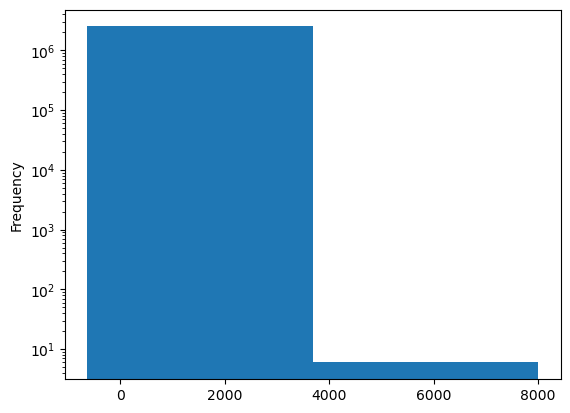

In [34]:
flow.flow.plot(kind='hist', bins=2)
plt.yscale('log')

<Axes: >

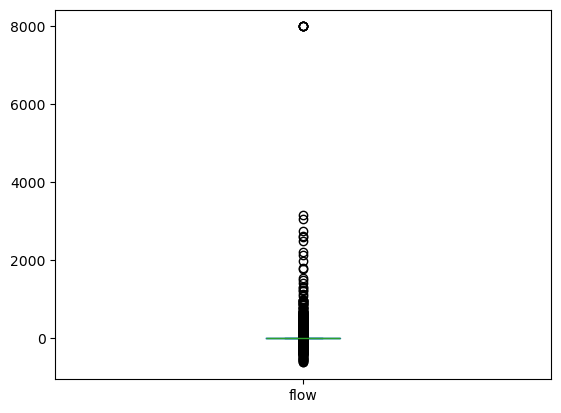

In [35]:
flow.flow.plot(kind='box')

In [36]:
#flow.set_index('timestamp').plot()

In [37]:
flow.shape[0]/2-1

1256917.0

In [38]:
flow.loc[flow.shape[0]/2:, 'flow'].agg(['min', 'max']) # all non-negative values

min       0
max    7999
Name: flow, dtype: int64

In [39]:
# divide flow into the two types of counts, in and out
departures = flow.loc[:flow.shape[0]/2-1].copy() #1st half
arrivals = flow.loc[flow.shape[0]/2:].copy() #2nd half

In [40]:
print(flow.shape)
print(departures.shape)
print(arrivals.shape)

(2513836, 2)
(1256918, 2)
(1256918, 2)


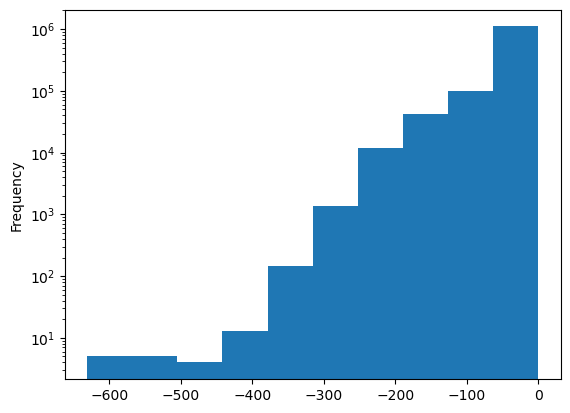

In [41]:
departures.flow.plot(kind='hist')
plt.yscale('log')

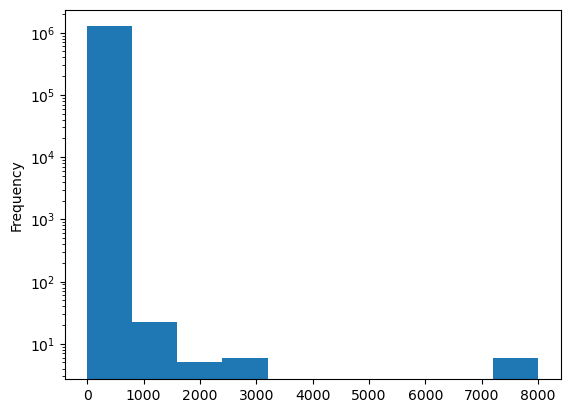

In [42]:
arrivals.flow.plot(kind='hist')
plt.yscale('log')

In [43]:
departures.duplicated().sum() # are all timestamps unique? no

np.int64(114)

In [44]:
#a mask
departures.duplicated().sum()

np.int64(114)

In [45]:
departures.loc[departures.duplicated(), 'timestamp'].dt.date.value_counts()
# when are times duplicated?

#including a mask inside .loc[] aka inside slicing

timestamp
2018-10-28    58
2017-10-29    56
Name: count, dtype: int64

In [46]:
departures.loc[departures.duplicated(), 'timestamp'].dt.day_name().unique()
# this is always on a Sunday

array(['Sunday'], dtype=object)

In [47]:
departures.loc[departures.duplicated(), 'timestamp'].dt.hour.unique() # very early in the morning
# fulfills all expectations of time change

array([2], dtype=int32)

In [48]:
# because local time changes with season, convert to UTC
departures['timestamp'] = departures['timestamp'].dt.tz_localize(
    'Europe/Berlin', ambiguous='infer').dt.tz_convert("UTC")
departures.duplicated().sum() # no more duplicates

np.int64(0)

In [49]:
arrivals['timestamp'] = arrivals['timestamp'].dt.tz_localize('Europe/Berlin', ambiguous='infer').dt.tz_convert("UTC")
arrivals.duplicated().sum()

np.int64(0)

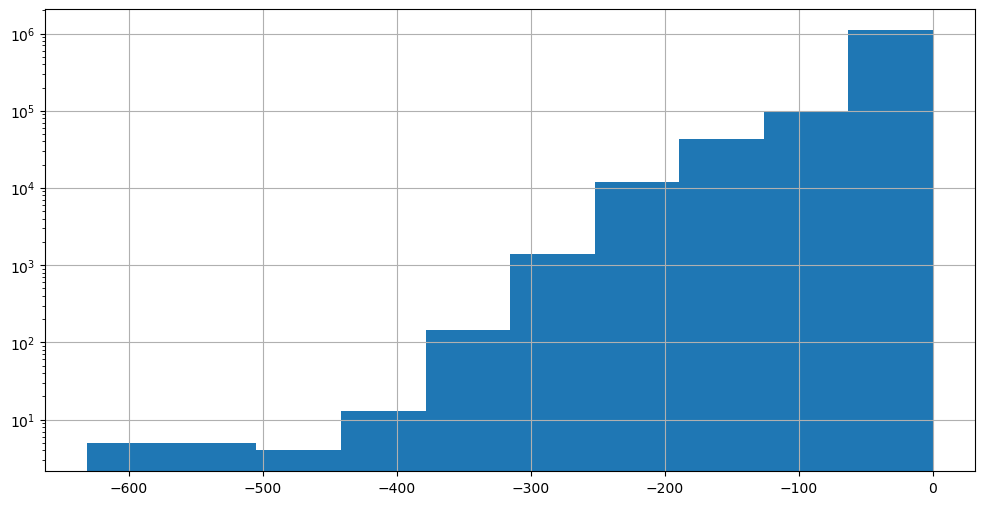

In [50]:
# what's the distribution of counts?
departures['flow'].hist(figsize=(12,6));
plt.yscale('log')
#arrivals['flow'].hist(figsize=(12,6)); # some numbers seem like outliers

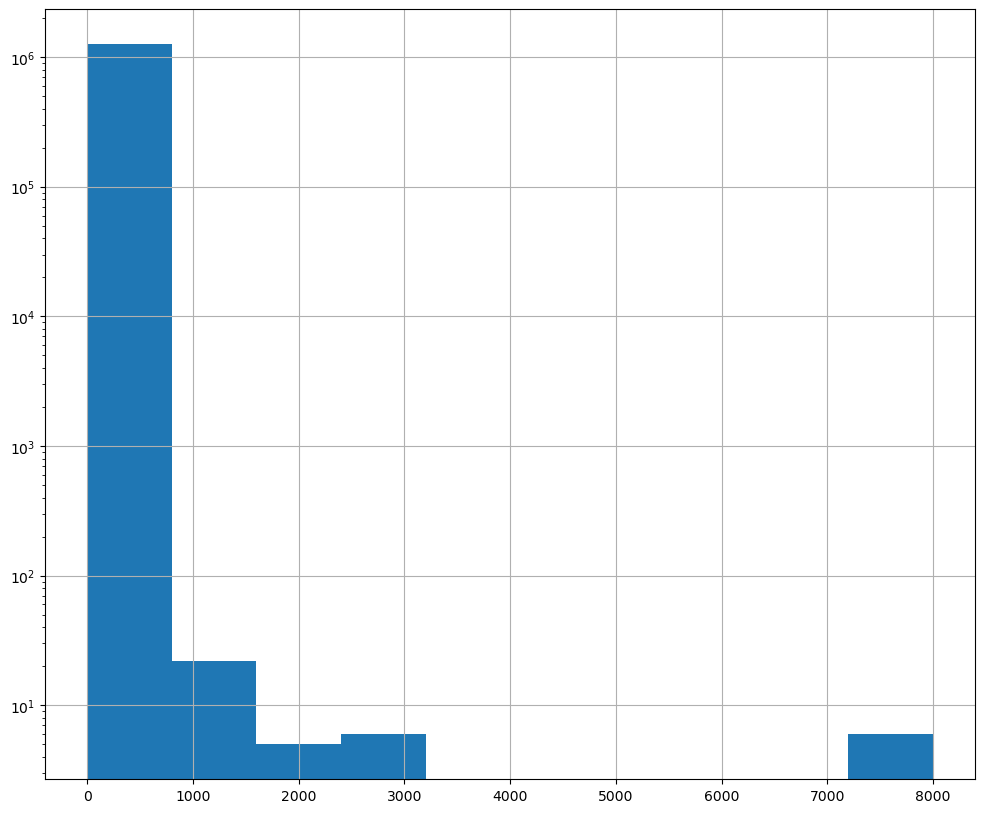

In [52]:
arrivals['flow'].hist(figsize=(12,10))#, bins=len(flow)/100); # some numbers seem like outliers
#plt.ylim(0,100)
plt.yscale('log')

In [53]:
arrivals.nlargest(20, 'flow') # 7999 is a pretty big gap from the rest of the figures

,timestamp,flow
2084055,2018-08-04 23:25:00+00:00,7999
2098359,2018-08-14 21:50:00+00:00,7999
2107004,2018-08-20 21:56:00+00:00,7999
2107005,2018-08-20 21:57:00+00:00,7999
2107009,2018-08-20 22:01:00+00:00,7999
2107010,2018-08-20 22:02:00+00:00,7999
2107023,2018-08-20 22:15:00+00:00,3148
2101589,2018-08-17 03:41:00+00:00,3042
1531827,2017-07-16 20:39:00+00:00,2755
2091430,2018-08-10 02:21:00+00:00,2629


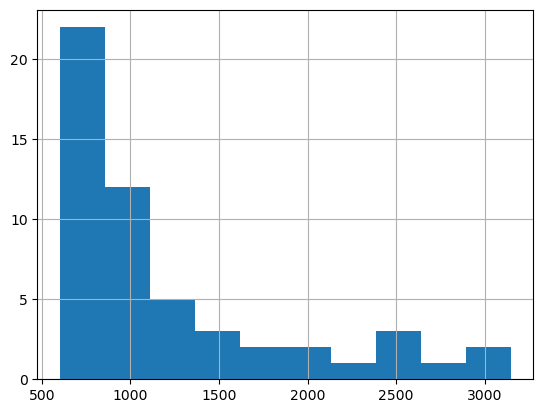

In [54]:
arrivals.loc[arrivals['flow'].between(600, 3500), 'flow'].hist(); # this part of the curve looks natural

<Axes: xlabel='timestamp'>

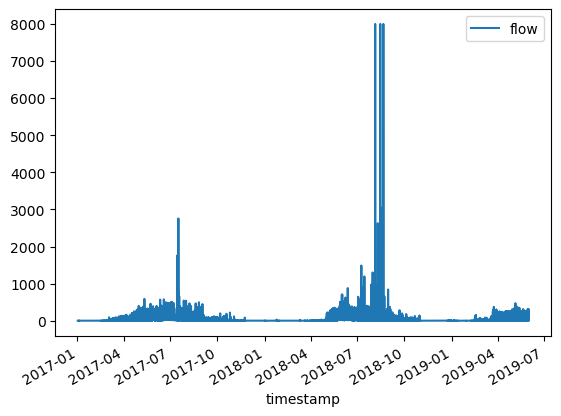

In [55]:
arrivals.plot(kind='line', x='timestamp', y='flow') # all the highest values cluster in a few days. measurement error?
# you can decide if these are outliers worth excluding or the future analyst's problem

# Humidity

In [56]:
humidity['humidity'].describe() # humidity should not be negative

count    1749.000000
mean       83.987816
std        26.501959
min      -100.000000
25%        79.330000
50%        91.070000
75%        96.610000
max       100.000000
Name: humidity, dtype: float64

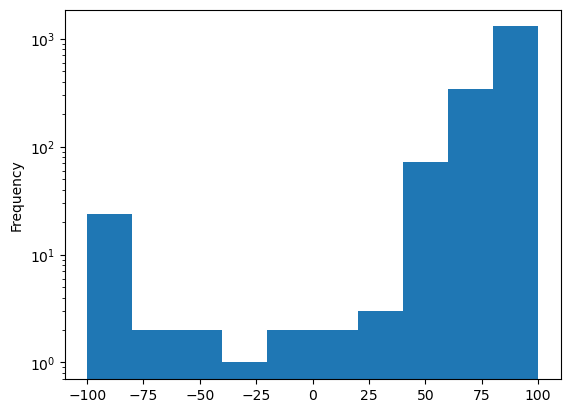

In [57]:
humidity.humidity.plot(kind='hist')
plt.yscale('log')

<Axes: xlabel='timestamp'>

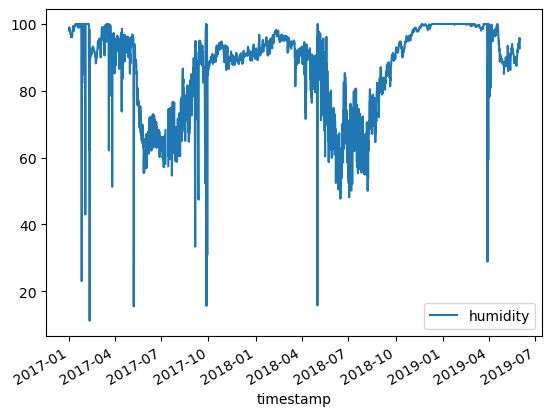

In [58]:
humidity2 = humidity.copy() # copy to see what happens when fixing values
humidity2['humidity'] = humidity2['humidity'].abs() # all positive values
humidity2.plot(kind='line', x='timestamp', y='humidity') # doesn't look unreasonable

In [59]:
humidity.tail()

,timestamp,humidity
1756,2019-05-29 14:00:00,92.87
1757,2019-05-30 02:00:00,94.77
1758,2019-05-30 14:00:00,94.90
1759,2019-05-31 02:00:00,95.84
1760,2019-05-31 14:00:00,92.79


In [60]:
humidity.loc[humidity['humidity'] < 0]

,timestamp,humidity
51,2017-01-27 01:00:00,-100.00
52,2017-01-27 13:00:00,-82.25
65,2017-02-03 01:00:00,-100.00
66,2017-02-03 13:00:00,-100.00
67,2017-02-04 01:00:00,-100.00
68,2017-02-04 13:00:00,-100.00
69,2017-02-05 01:00:00,-100.00
70,2017-02-05 13:00:00,-100.00
71,2017-02-06 01:00:00,-100.00
72,2017-02-06 13:00:00,-100.00


In [61]:
humidity['humidity'] = humidity['humidity'].abs() # correct original dataframe

In [ ]:
humidity.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1761 entries, 0 to 1760
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   timestamp  1761 non-null   datetime64[ns]
 1   humidity   1749 non-null   float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 27.6 KB


In [62]:
humidity.head()

,timestamp,humidity
0,2017-01-01 13:00:00,98.04
1,2017-01-02 01:00:00,98.61
2,2017-01-02 13:00:00,99.00
3,2017-01-03 01:00:00,98.49
4,2017-01-03 13:00:00,98.32


In [63]:
(humidity['timestamp'] - humidity['timestamp'].shift(1)).value_counts() # looks very regular if we assume the time changes

timestamp
0 days 12:00:00    1755
0 days 13:00:00       3
0 days 11:00:00       2
Name: count, dtype: int64

In [64]:
humidity['timestamp'].dt.tz_localize("Europe/Berlin", ambiguous='infer')
# cannot infer dst status

AmbiguousTimeError: 2017-10-29 02:00:00

In [65]:
# investigate problem dates
#humidity.loc[humidity['timestamp'].dt.year == 2017] # indexes 601:602
humidity.loc[humidity['timestamp'].dt.strftime('%Y-%m-%d') == '2017-10-29'] # indexes 601:602

,timestamp,humidity
601,2017-10-29 02:00:00,93.11
602,2017-10-29 13:00:00,93.30


In [66]:
humidity.loc[humidity['timestamp'].dt.strftime('%Y-%m-%d') == '2018-10-28'] # indexes 1329:1330

,timestamp,humidity
1329,2018-10-28 02:00:00,96.52
1330,2018-10-28 13:00:00,96.55


In [67]:
# zoom out a little to get the pattern of measurements
humidity.loc[598:604]

,timestamp,humidity
598,2017-10-27 14:00:00,93.94
599,2017-10-28 02:00:00,92.78
600,2017-10-28 14:00:00,92.81
601,2017-10-29 02:00:00,93.11
602,2017-10-29 13:00:00,93.30
603,2017-10-30 01:00:00,93.50
604,2017-10-30 13:00:00,91.68


In [68]:
humidity.loc[1326:1332]

# it seems all ambiguous dates (at 2am) are recorded BEFORE the clocks change

,timestamp,humidity
1326,2018-10-26 14:00:00,95.02
1327,2018-10-27 02:00:00,95.60
1328,2018-10-27 14:00:00,95.94
1329,2018-10-28 02:00:00,96.52
1330,2018-10-28 13:00:00,96.55
1331,2018-10-29 01:00:00,96.03
1332,2018-10-29 13:00:00,95.57


In [69]:
#In Germany, Daylight Saving Time (DST) ended on:

#🗓 Sunday, October 29, 2017
#🕓 At 03:00 AM, clocks were set back to 02:00 AM

In [70]:
#There were two different 02:00:00 timestamps on that day:
#2017-10-29 02:00:00+02:00 -> DST (CEST, UTC+2) -> Before clock change
#2017-10-29 02:00:00+01:00 -> Standard Time (CET, UTC+1) -> After clock change

In [71]:
pd.Series(True, index=humidity.index) # can we make a Series of True with the same shape as the 'humidity' column?

0       True
1       True
2       True
3       True
4       True
        ... 
1756    True
1757    True
1758    True
1759    True
1760    True
Length: 1761, dtype: bool

In [72]:
humidity['timestamp'].dt.tz_localize("Europe/Berlin", ambiguous=pd.Series(True, index=humidity.index))

#instead of inferring or asking the user, you’re telling pandas:
# If you find any ambiguous time (like repeated hour during DST shift), always choose the first (DST) one.

#pandas looks up the DST transition rules for the "Europe/Berlin" timezone in the year of your data — e.g., 2017 — and:
# It sees that on 2017-10-29, clocks moved backward from 03:00 → 02:00
# That means any time between 02:00:00 and 02:59:59 occurs twice
# If your datetime is exactly in that range (e.g. 2017-10-29 02:00:00), pandas flags it as ambiguous ❗

0      2017-01-01 13:00:00+01:00
1      2017-01-02 01:00:00+01:00
2      2017-01-02 13:00:00+01:00
3      2017-01-03 01:00:00+01:00
4      2017-01-03 13:00:00+01:00
                  ...           
1756   2019-05-29 14:00:00+02:00
1757   2019-05-30 02:00:00+02:00
1758   2019-05-30 14:00:00+02:00
1759   2019-05-31 02:00:00+02:00
1760   2019-05-31 14:00:00+02:00
Name: timestamp, Length: 1761, dtype: datetime64[ns, Europe/Berlin]

In [73]:
# any ambiguous times ARE in daylight saving (summer time)
humidity['timestamp'] = humidity['timestamp'].dt.tz_localize("Europe/Berlin", ambiguous=pd.Series(True, index=humidity.index)).dt.tz_convert("UTC")

In [74]:
(humidity['timestamp'] - humidity['timestamp'].shift(1)).value_counts() # looks very regular if we assume the time changes

#now all diffs are 12 hours! no 13 hours

timestamp
0 days 12:00:00    1760
Name: count, dtype: int64

In [75]:
humidity.duplicated().sum()

np.int64(0)

In [77]:
humidity.loc[humidity['humidity'].isnull()] # look at null values for pattern

# was there some problem at the site for sereral days? storm? sickness?

,timestamp,humidity
378,2017-07-09 12:00:00+00:00,NaN
379,2017-07-10 00:00:00+00:00,NaN
380,2017-07-10 12:00:00+00:00,NaN
381,2017-07-11 00:00:00+00:00,NaN
382,2017-07-11 12:00:00+00:00,NaN
383,2017-07-12 00:00:00+00:00,NaN
384,2017-07-12 12:00:00+00:00,NaN
385,2017-07-13 00:00:00+00:00,NaN
386,2017-07-13 12:00:00+00:00,NaN
387,2017-07-14 00:00:00+00:00,NaN


In [78]:
#what to do? drop? impute (using df.column.fillna())?

# Temperature

In [79]:
temperature.head()

,timestamp,temperature
0,2017-01-01 14:10:00,NaN
1,2017-01-01 14:15:00,12.34
2,2017-01-01 14:20:00,12.27
3,2017-01-01 14:25:00,12.28
4,2017-01-01 14:30:00,12.36


In [80]:
# convert to UTC
temperature['timestamp'] = temperature['timestamp'].dt.tz_localize("Europe/Berlin", ambiguous="infer").dt.tz_convert("UTC")

In [81]:
temperature["temperature"].describe() # these temps seem high at first glance, but normal if measured inside the beehive

count    251398.000000
mean         22.609671
std          11.702222
min          -7.260000
25%          12.450000
50%          24.480000
75%          34.220000
max          37.530000
Name: temperature, dtype: float64

In [82]:
temperature.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 253430 entries, 0 to 253429
Data columns (total 2 columns):
 #   Column       Non-Null Count   Dtype              
---  ------       --------------   -----              
 0   timestamp    253430 non-null  datetime64[ns, UTC]
 1   temperature  251398 non-null  float64            
dtypes: datetime64[ns, UTC](1), float64(1)
memory usage: 3.9 MB


In [83]:
# where is data missing? several whole days clustered together (one whole day by itself), and scattered at other times
temperature.loc[temperature['temperature'].isna(), 'timestamp'].dt.date.value_counts()

timestamp
2017-07-10    288
2017-07-11    288
2017-07-12    288
2017-07-13    288
2019-03-09    288
2017-07-09    249
2017-07-14    153
2018-04-28    142
2018-05-16     32
2019-03-08     15
2017-01-01      1
Name: count, dtype: int64

In [84]:
temperature.duplicated().sum()

np.int64(0)

# Weight

In [86]:
# same logic applies as with humidity
weight['timestamp'] = weight['timestamp'].dt.tz_localize("Europe/Berlin", ambiguous=pd.Series(True, index=weight.index)).dt.tz_convert("UTC")
weight.head()

TypeError: Already tz-aware, use tz_convert to convert.

In [87]:
weight.head()

,timestamp,weight,weight_no_null
0,2017-01-01 12:00:00+00:00,50736.79,50736.79
1,2017-01-02 00:00:00+00:00,50700.68,50700.68
2,2017-01-02 12:00:00+00:00,50614.91,50614.91
3,2017-01-03 00:00:00+00:00,50739.82,50739.82
4,2017-01-03 12:00:00+00:00,50799.75,50799.75


In [88]:
weight.duplicated().sum()

np.int64(0)

In [89]:
weight['weight'].describe() # I'd guess measurements are in grams

# cannot have negative weight

count     1761.000000
mean     56807.637313
std      16869.133461
min       -172.440000
25%      49800.570000
50%      57954.430000
75%      67302.930000
max      92042.230000
Name: weight, dtype: float64

In [83]:
#step 1 develop the mask
weight.weight < 0

0       False
1       False
2       False
3       False
4       False
        ...  
1756    False
1757    False
1758    False
1759    False
1760    False
Name: weight, Length: 1761, dtype: bool

In [90]:
#step 2 put the mask inside a df[]
weight[weight.weight < 0]
weight[weight.timestamp.dt.year == 2018]

,timestamp,weight,weight_no_null
729,2018-01-01 00:00:00+00:00,50651.67,50651.67
730,2018-01-01 12:00:00+00:00,50726.30,50726.30
731,2018-01-02 00:00:00+00:00,50630.89,50630.89
732,2018-01-02 12:00:00+00:00,50751.66,50751.66
733,2018-01-03 00:00:00+00:00,50607.15,50607.15
...,...,...,...
1454,2018-12-29 12:00:00+00:00,65820.42,65820.42
1455,2018-12-30 00:00:00+00:00,65726.06,65726.06
1456,2018-12-30 12:00:00+00:00,65675.21,65675.21
1457,2018-12-31 00:00:00+00:00,65854.36,65854.36


In [91]:
weight[weight['weight'] < 0] # investigate negative weights

#boolean masking

,timestamp,weight,weight_no_null
964,2018-04-28 12:00:00+00:00,-170.61,-170.61
965,2018-04-29 00:00:00+00:00,-172.44,-172.44
966,2018-04-29 12:00:00+00:00,-167.10,-167.10
1001,2018-05-17 00:00:00+00:00,-101.54,-101.54
1061,2018-06-16 00:00:00+00:00,-157.49,-157.49
1062,2018-06-16 12:00:00+00:00,-143.38,-143.38
1063,2018-06-17 00:00:00+00:00,-157.63,-157.63
1064,2018-06-17 12:00:00+00:00,-149.62,-149.62
1065,2018-06-18 00:00:00+00:00,-162.12,-162.12
1066,2018-06-18 12:00:00+00:00,-147.43,-147.43


(-1000.0, 1000.0)

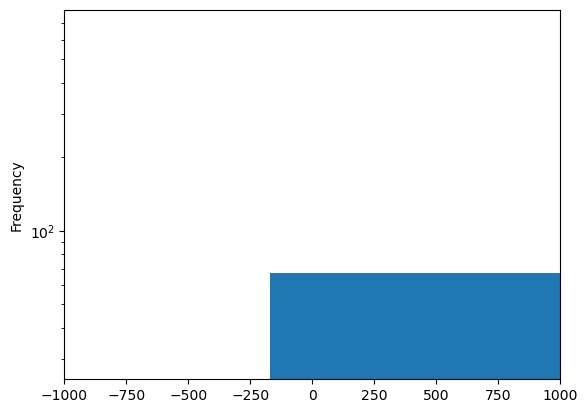

In [92]:
# plot them to look for pattern
from matplotlib import pyplot as plt

#weight.plot(kind='line', x='timestamp', y='weight', figsize=(12, 6))
#plt.axhline(0)

weight.weight.plot(kind='hist')
plt.yscale('log')
plt.xlim(-1000,1000)

# they're really not even visible

In [93]:
# test out making negatives positive
weight2 = weight.copy()
weight2['weight'] = weight2['weight'].abs()
#weight2.plot(kind='line', x='åtimestamp', y='weight', figsize=(12, 6))
#plt.axhline(0) # looks reasonable

In [94]:
weight['weight'] = weight['weight'].abs()

# Reassembly and regularity

## Flow

In [95]:
# merge flow figures back into one dataframe
flow = departures.merge(arrivals, on='timestamp', how='outer', suffixes=['_out', '_in'])
flow = flow.sort_values(by='timestamp')
flow

,timestamp,flow_out,flow_in
0,2017-01-01 13:15:00+00:00,0,0
1,2017-01-01 13:16:00+00:00,0,0
2,2017-01-01 13:17:00+00:00,0,0
3,2017-01-01 13:18:00+00:00,0,0
4,2017-01-01 13:19:00+00:00,0,0
...,...,...,...
1256913,2019-05-31 12:11:00+00:00,-241,128
1256914,2019-05-31 12:12:00+00:00,-226,140
1256915,2019-05-31 12:13:00+00:00,-208,144
1256916,2019-05-31 12:14:00+00:00,-217,146


In [96]:
# timestamps still aren't perfectly regular
(flow['timestamp'] - flow['timestamp'].shift(1)).value_counts()

timestamp
0 days 00:01:00    1256857
0 days 00:02:00         56
5 days 09:32:00          1
0 days 11:56:00          1
0 days 02:44:00          1
1 days 01:19:00          1
Name: count, dtype: int64

In [97]:
# create a regular, one-minute interval
# maybe this could be done with resample?
start_dt = flow['timestamp'].min()
end_dt = flow['timestamp'].max()
one_minute_index = pd.Series(
    pd.date_range(start=start_dt, end=end_dt, freq='1min'),
    name='timestamp'
)
one_minute_index

0         2017-01-01 13:15:00+00:00
1         2017-01-01 13:16:00+00:00
2         2017-01-01 13:17:00+00:00
3         2017-01-01 13:18:00+00:00
4         2017-01-01 13:19:00+00:00
                     ...           
1267136   2019-05-31 12:11:00+00:00
1267137   2019-05-31 12:12:00+00:00
1267138   2019-05-31 12:13:00+00:00
1267139   2019-05-31 12:14:00+00:00
1267140   2019-05-31 12:15:00+00:00
Name: timestamp, Length: 1267141, dtype: datetime64[ns, UTC]

In [98]:
flow = flow.merge(one_minute_index, on='timestamp', how='right') # regular measurements will help time series analysis
flow

,timestamp,flow_out,flow_in
0,2017-01-01 13:15:00+00:00,0.0,0.0
1,2017-01-01 13:16:00+00:00,0.0,0.0
2,2017-01-01 13:17:00+00:00,0.0,0.0
3,2017-01-01 13:18:00+00:00,0.0,0.0
4,2017-01-01 13:19:00+00:00,0.0,0.0
...,...,...,...
1267136,2019-05-31 12:11:00+00:00,-241.0,128.0
1267137,2019-05-31 12:12:00+00:00,-226.0,140.0
1267138,2019-05-31 12:13:00+00:00,-208.0,144.0
1267139,2019-05-31 12:14:00+00:00,-217.0,146.0


In [99]:
(flow['timestamp'] - flow['timestamp'].shift(1)).value_counts()

timestamp
0 days 00:01:00    1267140
Name: count, dtype: int64

In [100]:
#or we could have used df.asfreq('1min')

## Humidity

In [101]:
(humidity['timestamp'] - humidity['timestamp'].shift(1)).value_counts()
# already perfectly regular

timestamp
0 days 12:00:00    1760
Name: count, dtype: int64

## Temperature

In [102]:
(temperature['timestamp'] - temperature['timestamp'].shift(1)).value_counts()
# already perfectly regular

timestamp
0 days 00:05:00    253429
Name: count, dtype: int64

## Weight

In [103]:
(weight['timestamp'] - weight['timestamp'].shift(1)).value_counts()
# already perfectly regular

timestamp
0 days 12:00:00    1760
Name: count, dtype: int64

# Data writes

In [107]:
# be sure to create folders first
sink = 'C:/Users/Marcus/Documents/DSAI/Azure_WBS/silver/'

flow.to_parquet(f'{sink}flow/schwartau__{pd.Timestamp.now().strftime("%Y-%m-%dT%H-%M-%S")}.parquet', index=False)
humidity.to_parquet(f'{sink}humidity/schwartau__{pd.Timestamp.now().strftime("%Y-%m-%dT%H-%M-%S")}.parquet', index=False)
temperature.to_parquet(f'{sink}temperature/schwartau__{pd.Timestamp.now().strftime("%Y-%m-%dT%H-%M-%S")}.parquet', index=False)
weight.to_parquet(f'{sink}weight/schwartau__{pd.Timestamp.now().strftime("%Y-%m-%dT%H-%M-%S")}.parquet', index=False)

In [ ]:
import pandas as pd
pd.read_parquet('C:/Users/Marcus/Documents/DSAI/Azure_WBS/silver/flow/schwartau__.parquet')

OSError: [Errno 22] Invalid argument: 'C:/Users/Marcus/Documents/DSAI/Azure_WBS/silver/flow/schwartau__*.parquet'